---
tags: [integration, optimization, variational]
---

# CUDA-Qサポート

このページでは、具体的な最適化問題を通して、Qamomileの[CUDA-Q](https://nvidia.github.io/cuda-quantum/latest/)量子SDK連携を紹介します。
このチュートリアルでは、小さなMaxCutインスタンスに対するQAOA最適化を例に、Qamomileの量子カーネルをCUDA-Q向けにトランスパイルし、サンプリングと期待値評価を行います。
後半では、同じQAOA回路をCPUとGPUシミュレータで実行し、サンプル結果と実行時間を比較します。
その過程で、生成されたCUDA-Qソースを確認し、Qamomileの`STATIC` modeと`RUNNABLE` modeの違いも確認します。

In [56]:
# QamomileをCUDA-Q用の追加依存と一緒にpipからインストールします。
# CUDA-Qの利用環境に合うオプション依存グループを選んでください。
# !pip install "qamomile[cudaq-cu12]"  # CUDA 12.x, Linux
# !pip install "qamomile[cudaq-cu13]"  # CUDA 13.x, Linux or macOS ARM64

In [57]:
import os
import platform
import subprocess
import time
from collections import Counter

import cudaq
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from scipy.optimize import minimize

import qamomile.circuit as qmc
import qamomile.observable as qm_o
from qamomile.cudaq import CudaqExecutor, CudaqTranspiler, ExecutionMode
from qamomile.optimization.binary_model import BinaryModel

## MaxCut問題

CUDA-Q連携の説明に集中するため、[MaxCutに対するQAOAチュートリアル](../algorithm/qaoa_maxcut.ipynb)と同じ5ノードの小さなグラフを使います。
$\sum_{(i,j) \in E}(1 - s_i s_j)/2$の最大化は、定数項を除けば、反強磁性Isingハミルトニアン$H_C = \sum_{(i,j) \in E} s_i s_j$の最小化に対応します。
重みなしMaxCutでは、すべての$J_{ij} = 1$、$h_i = 0$なので、これらの係数をそのまま`BinaryModel.from_ising`に渡します。
ここで作るモデルは、QAOAの量子カーネルに渡す`quad` / `linear`辞書と、測定結果をスピン値$(+1 / -1)$に戻すために使います。

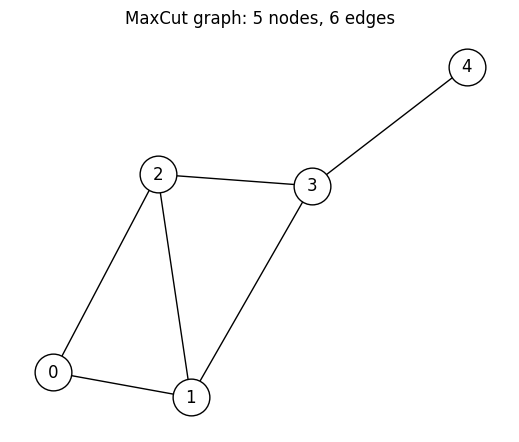

In [58]:
G = nx.Graph()
G.add_edges_from([(0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (3, 4)])
num_nodes = G.number_of_nodes()

ising_quad: dict[tuple[int, int], float] = {
    tuple(sorted((i, j))): 1.0 for i, j in G.edges()
}
ising_linear: dict[int, float] = {}
spin_model = BinaryModel.from_ising(linear=ising_linear, quad=ising_quad)
# 問題の構造はグラフから一意に決まります。重みなしMaxCutでは、quad項は辺と
# 1対1に対応し、linear項は存在しません。
assert len(spin_model.quad) == G.number_of_edges()
assert len(spin_model.linear) == 0

pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(5, 4))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="white",
    node_size=700,
    edgecolors="black",
)
plt.title(f"MaxCut graph: {num_nodes} nodes, {G.number_of_edges()} edges")
plt.show()

## `@qkernel`によるQAOAアンザッツの構築

サンプリング用のQAOAアンザッツを、再利用可能な量子カーネルとして書きます。
レシピは[MaxCutに対するQAOAチュートリアル](../algorithm/qaoa_maxcut.ipynb)と同じです。計算基底の一様な重ね合わせ状態を準備した後、コスト層とミキサー層を$p$回交互に適用し、最後に計算基底で測定します。

:::{tip}
Qamomileの回転ゲートは$e^{-i\theta/2}$という規約に従います。
そのため、$1/2$係数の扱いはコスト層とミキサー層で少し異なります。
ミキサー層では`rx`に$2\beta$を渡すので、$1/2$が打ち消され、教科書通りの$e^{-i\beta X}$になります。
一方、コスト層では`rzz`に$J_{ij} \cdot \gamma$を渡すため、$1/2$は残ります。
この係数の違いは変分パラメータ$\gamma$に吸収しています。つまり、ここで使う$\gamma$は教科書のQAOAの$\gamma$の2倍に相当します。
:::

In [59]:
@qmc.qkernel
def superposition(n: qmc.UInt) -> qmc.Vector[qmc.Qubit]:
    q = qmc.qubit_array(n, name="q")
    for i in qmc.range(n):
        q[i] = qmc.h(q[i])
    return q


@qmc.qkernel
def cost_layer(
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    q: qmc.Vector[qmc.Qubit],
    gamma: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    for (i, j), Jij in quad.items():
        q[i], q[j] = qmc.rzz(q[i], q[j], angle=Jij * gamma)
    for i, hi in linear.items():
        q[i] = qmc.rz(q[i], angle=hi * gamma)
    return q


@qmc.qkernel
def mixer_layer(
    q: qmc.Vector[qmc.Qubit],
    beta: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    n = q.shape[0]
    for i in qmc.range(n):
        q[i] = qmc.rx(q[i], angle=2.0 * beta)
    return q


@qmc.qkernel
def qaoa_ansatz(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    n: qmc.UInt,
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
) -> qmc.Vector[qmc.Bit]:
    q = superposition(n)
    for layer in qmc.range(p):
        q = cost_layer(quad, linear, q, gammas[layer])
        q = mixer_layer(q, betas[layer])
    return qmc.measure(q)

`qaoa_ansatz.draw(...)`でQamomileの回路図を描画できます。
問題の構造を決める引数(`p`、`quad`、`linear`、`n`)には具体値を渡し、層の形が見えるようにします。
一方、`gammas` / `betas`には値を渡さず、後で決めるパラメータとして残します。

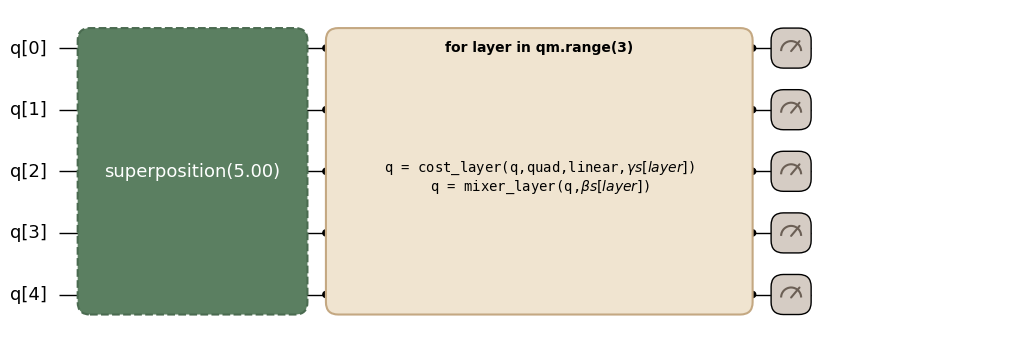

In [60]:
p = 3  # QAOAの層数
qaoa_ansatz.draw(
    p=p,
    quad=spin_model.quad,
    linear=spin_model.linear,
    n=num_nodes,
)

## CUDA-Qへのトランスパイル

`CudaqTranspiler`は、他の量子SDKと同じように`transpile()`で使えます。
問題の構造を決める引数は`bindings`で固定し、`gammas` / `betas`はランタイムパラメータとして残します。

In [61]:
transpiler = CudaqTranspiler()
executor = CudaqExecutor()

executable = transpiler.transpile(
    qaoa_ansatz,
    bindings={
        "p": p,
        "quad": spin_model.quad,
        "linear": spin_model.linear,
        "n": num_nodes,
    },
    parameters=["gammas", "betas"],
)

`executable.get_first_circuit()`で、CUDA-Q向けに生成されたQamomile側の`CudaqKernelArtifact`を取り出せます。
これは生成された`@cudaq.kernel`関数を扱うためのラッパーであり、CUDA-Q本体のPythonパッケージが提供する型ではありません。
artifactは、生成されたCUDA-Q量子カーネルのPythonソース文字列を確認できる形で保持しています。また、$2p$個のQAOA角度(`gammas[0..p-1]`、`betas[0..p-1]`)が名前付きランタイムパラメータとして残っています。
`type(...)`、量子ビット数、パラメータ数で確認し、生成されたソースも見てみましょう。
このソース文字列は、QamomileがCUDA-Qに渡した内容を正確に確認したい場合に便利です。たとえば、下の`rzz`層のようなゲート分解も確認できます。

In [62]:
cudaq_artifact = executable.get_first_circuit()
assert (
    cudaq_artifact is not None
)  # transpile()はここで必ず1つの量子セグメントを生成する
# `num_qubits`と`param_count`は問題設定から一意に決まります。
# 量子ビット数はグラフのノード数と一致し、ランタイムパラメータ数は層ごとに
# (gamma | beta)の組が1つずつ、合計2pになります。
assert cudaq_artifact.num_qubits == num_nodes
assert cudaq_artifact.param_count == 2 * p
assert cudaq_artifact.execution_mode == ExecutionMode.STATIC
assert len(executable.parameter_names) == 2 * p
print(type(cudaq_artifact).__name__)
print("execution_mode :", cudaq_artifact.execution_mode.value)
print("num_qubits     :", cudaq_artifact.num_qubits)
print("param_count    :", cudaq_artifact.param_count)
print("parameter_names:", executable.parameter_names)

assert "@cudaq.kernel" in cudaq_artifact.source
assert "x.ctrl" in cudaq_artifact.source
assert "rz(" in cudaq_artifact.source
print(cudaq_artifact.source)

CudaqKernelArtifact
execution_mode : static
num_qubits     : 5
param_count    : 6
parameter_names: ['gammas[0]', 'betas[0]', 'gammas[1]', 'betas[1]', 'gammas[2]', 'betas[2]']
@cudaq.kernel
def _qamomile_kernel(thetas: list[float]):
    q = cudaq.qvector(5)
    __b0 = False
    __b1 = False
    __b2 = False
    __b3 = False
    __b4 = False
    h(q[0])
    h(q[1])
    h(q[2])
    h(q[3])
    h(q[4])
    x.ctrl(q[0], q[1])
    rz((1.0) * (thetas[0]), q[1])
    x.ctrl(q[0], q[1])
    x.ctrl(q[0], q[2])
    rz((1.0) * (thetas[0]), q[2])
    x.ctrl(q[0], q[2])
    x.ctrl(q[1], q[2])
    rz((1.0) * (thetas[0]), q[2])
    x.ctrl(q[1], q[2])
    x.ctrl(q[1], q[3])
    rz((1.0) * (thetas[0]), q[3])
    x.ctrl(q[1], q[3])
    x.ctrl(q[2], q[3])
    rz((1.0) * (thetas[0]), q[3])
    x.ctrl(q[2], q[3])
    x.ctrl(q[3], q[4])
    rz((1.0) * (thetas[0]), q[4])
    x.ctrl(q[3], q[4])
    rx((thetas[1]) * (2.0), q[0])
    rx((thetas[1]) * (2.0), q[1])
    rx((thetas[1]) * (2.0), q[2])
    rx((thetas[1

各ランタイムパラメータは、実行時まで未バインドのまま残ります。
そのため、`gammas` / `betas`のバインドは回路の作り直しではなく、CUDA-Q側でのパラメータ値の更新として扱われます。
Ising係数、量子ビット数、層数といった問題構造はトランスパイル時に固定され、ランタイム入力として残るのは変分角度だけです。

## `CudaqExecutor`によるQAOAサンプリング

`executable.sample(executor, bindings=..., shots=...)`は`SampleJob`を返します。
`.result()`で得られる`SampleResult`は、`BinaryModel.decode_from_sampleresult`でスピン変数$(+1 / -1)$の`BinarySampleSet`へデコードできます。
これにより、追加の変換なしでカット辺を数えられます。

In [63]:
rng = np.random.default_rng(42)
init_params = rng.uniform(-np.pi / 2, np.pi / 2, 2 * p)
init_gammas = list(init_params[:p])
init_betas = list(init_params[p:])
docs_test_mode = os.environ.get("QAMOMILE_DOCS_TEST") == "1"
sample_shots = 256 if docs_test_mode else 2000
maxiter = 20 if docs_test_mode else 100

# パラメータ化されたexecutableをサンプリングし、ビット列をIsingエネルギーへデコードします。
sample_result = executable.sample(
    executor,
    bindings={"gammas": init_gammas, "betas": init_betas},
    shots=sample_shots,
).result()

decoded = spin_model.decode_from_sampleresult(sample_result)
print(f"Mean energy at random init: {decoded.energy_mean():+.4f}")

Mean energy at random init: -0.6410


## QAOAパラメータの最適化

同じ`executable`を異なる`(gammas, betas)`で繰り返し呼び出すのが、QAOAの最適化ループの基本形です。
`transpiler.transpile()`を1回呼び、その後は`executable.sample()`を何度も呼び出します。
この例では、サンプリングとデコードの処理を`cost_fn()`として定義し、SciPyの`minimize`関数で最適化します。
古典最適化器は`(gammas, betas)`を更新しながら、サンプリングされたIsingエネルギーの平均を下げていきます。
各反復では、同じ`executable`と`CudaqExecutor`を再利用します。

In [64]:
# 1つのexecutableを古典目的関数の中で再利用します。
cost_history: list[float] = []


def cost_fn(params: np.ndarray) -> float:
    result = executable.sample(
        executor,
        bindings={"gammas": list(params[:p]), "betas": list(params[p:])},
        shots=sample_shots,
    ).result()
    energy = spin_model.decode_from_sampleresult(result).energy_mean()
    cost_history.append(energy)
    return energy


# COBYLAでサンプリング平均エネルギーを最適化します。
res = minimize(cost_fn, init_params, method="COBYLA", options={"maxiter": maxiter})

opt_gammas = list(res.x[:p])
opt_betas = list(res.x[p:])
print(f"Optimized mean energy: {res.fun:+.4f}")
print(f"Optimal gammas       : {[round(float(v), 4) for v in opt_gammas]}")
print(f"Optimal betas        : {[round(float(v), 4) for v in opt_betas]}")

Optimized mean energy: -2.5870
Optimal gammas       : [1.6877, -1.137, 1.1355]
Optimal betas        : [-0.1229, -1.9608, 1.2592]


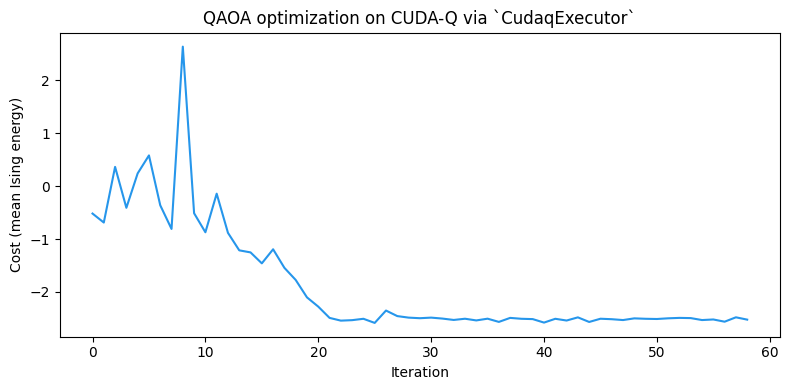

In [65]:
# 最適化の過程における目的関数の変化をプロットします。
plt.figure(figsize=(8, 4))
plt.plot(cost_history, color="#2696EB")
plt.xlabel("Iteration")
plt.ylabel("Cost (mean Ising energy)")
plt.title("QAOA optimization on CUDA-Q via `CudaqExecutor`")
plt.tight_layout()
plt.show()

サンプリングには乱数が入るため、最適化の軌跡や最終的な標本平均エネルギーは実行ごとに少し変わる場合があります。
CUDA-Q targetを変えた場合も、使用するシミュレータ実装の違いで同様の揺らぎが出ることがあります。
それでも、この5ノードグラフ上の$H_C$の基底状態エネルギー付近までは収束するはずです。
ここで得た最適パラメータ(`opt_gammas`、`opt_betas`)を、以降の例でも使います。

## 期待値計算

Qamomileでは、量子回路の出力に対する期待値を量子カーネル内の`qmc.expval(...)`で記述します。
これをCUDA-Qへトランスパイルすると、`ExecutableProgram.run(executor, bindings=...)`で呼び出せる実行可能オブジェクトになります。
CUDA-Q向けの`run()`は、Qamomileのパラメータ情報を使ってランタイムパラメータをバインドし、そのうえでCUDA-Qの`observe` APIを呼び出します。

ここではまずQamomileの`run()`経路を使い、その後で生成済みのCUDA-Q artifactを`executor.estimate(...)`へ直接渡す低レベルの経路を見ます。

### `run()`

まず$H_C = \sum_{(i,j) \in E} Z_i Z_j$をQamomileの`Hamiltonian`として組み立てます。
その後、期待値計算用の量子カーネルをトランスパイルし、最適化済みQAOAパラメータで評価します。

In [66]:
cost_hamiltonian = qm_o.Hamiltonian()
for (i, j), Jij in spin_model.quad.items():
    cost_hamiltonian.add_term(
        (qm_o.PauliOperator(qm_o.Pauli.Z, i), qm_o.PauliOperator(qm_o.Pauli.Z, j)),
        Jij,
    )
for i, hi in spin_model.linear.items():
    cost_hamiltonian.add_term((qm_o.PauliOperator(qm_o.Pauli.Z, i),), hi)

# 期待値計算用の量子カーネルを定義します。
@qmc.qkernel
def qaoa_expval(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    n: qmc.UInt,
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
    obs: qmc.Observable,
) -> qmc.Float:
    q = superposition(n)
    for layer in qmc.range(p):
        q = cost_layer(quad, linear, q, gammas[layer])
        q = mixer_layer(q, betas[layer])
    return qmc.expval(q, obs)


# 期待値計算用の量子カーネルをトランスパイルし、`run()`で評価します。
expval_executable = transpiler.transpile(
    qaoa_expval,
    bindings={
        "p": p,
        "quad": spin_model.quad,
        "linear": spin_model.linear,
        "n": num_nodes,
        "obs": cost_hamiltonian,
    },
    parameters=["gammas", "betas"],
)
energy_from_run = expval_executable.run(
    executor,
    bindings={"gammas": opt_gammas, "betas": opt_betas},
).result()

print(f"ExecutableProgram.run: {energy_from_run:+.10f}")
assert np.isfinite(energy_from_run)

ExecutableProgram.run: -2.5324217877


QamomileのAPIだけで扱う場合は、`ExecutableProgram.run(...)`を使うのがおすすめです。
Observableと名前付きランタイムパラメータの`bindings`は、Qamomileの`ExecutableProgram`が管理します。

次のセクションでは、より低レベルの経路を開き、`transpile()`が出力したCUDA-Q artifactを`executor.estimate(...)`に直接渡します。

### `cudaq.observe`

`STATIC` CUDA-Q artifactでは、`CudaqExecutor.estimate(circuit, hamiltonian, params=...)`が内部で`cudaq.observe()`を呼び出します。
上の測定付きQAOAアンザッツも、状態準備回路としてそのまま使えます。`STATIC` artifactでは、Qamomileは終端測定を生成されたCUDA-Q量子カーネルに書き込みません。
サンプリング時には最後の測定を別途扱うため、同じartifactを`cudaq.observe()`にも渡せます。
QAOAの最適化でも、同じ回路を保ったまま`ExecutableProgram.sample()`とデコードの組み合わせを`executor.estimate(circuit, hamiltonian, params=...)`に置き換えられます。

`executor.estimate(...)`に直接渡す場合は、CUDA-Q artifactが期待するフラットなパラメータ順を自分で用意します。

In [67]:
unbound_circuit = executable.get_first_circuit()
assert unbound_circuit is not None
assert unbound_circuit.execution_mode == ExecutionMode.STATIC
print(f"artifact type       : {type(unbound_circuit).__name__}")
print(f"artifact param_count: {unbound_circuit.param_count}")

# CUDA-Qはランタイムパラメータを「artifactに登録された順序のフラットなリスト」
# として要求します。登録順は回路を出力したときの初出順で決まるため、QAOAでは
# gammas[0], betas[0], gammas[1], betas[1], ...と層ごとに交互の順になります。
# 「すべてのgammasのあとにすべてのbetas」という順序ではない点に注意してください。
# 順序を推測しなくて済むよう、`ExecutableProgram`から登録順を読み取り、
# 名前で値を引いてフラットなリストに整えます。
named_values = {f"gammas[{i}]": opt_gammas[i] for i in range(p)}
named_values.update({f"betas[{i}]": opt_betas[i] for i in range(p)})
flat_params = [named_values[name] for name in executable.parameter_names]
# ランタイムパラメータは2p個のQAOA角度のみです。
assert len(executable.parameter_names) == 2 * p
assert len(flat_params) == 2 * p
print(f"artifact parameter order: {executable.parameter_names}")

energy_via_estimate = executor.estimate(
    unbound_circuit, cost_hamiltonian, params=flat_params
)
print(f"executor.estimate: {energy_via_estimate:+.10f}")
assert np.isclose(energy_from_run, energy_via_estimate, atol=1e-10)

artifact type       : CudaqKernelArtifact
artifact param_count: 6
artifact parameter order: ['gammas[0]', 'betas[0]', 'gammas[1]', 'betas[1]', 'gammas[2]', 'betas[2]']
executor.estimate: -2.5324217877


`run()`と`executor.estimate(...)`の両方の経路は数値精度の範囲で一致します。
同じQAOA状態を、同じIsingコストハミルトニアンに対して評価しているためです。
また、最適化後パラメータでのこのノイズなし期待値は、先ほど出力した標本平均エネルギーともショットノイズの範囲で一致するはずです。

## CUDA-Q targetの選択: GPU targetの利用

`CUDA-Q target`は、CUDA-Qが量子カーネル呼び出しに使う実行先です。たとえばCPUシミュレータの`qpp-cpu`、GPUシミュレータの`nvidia`、設定済みの実機QPU向けtargetなどがあります。
`CudaqExecutor()`は現在選択されているCUDA-Q targetを使います。targetを明示しない場合はCUDA-Qの既定targetが使われるため、上の例はCPUのみのローカル環境でも追加設定なしで実行できます。
`CudaqExecutor(target=...)`または`CudaqTranspiler.executor(target=...)`はtargetを明示的に選択します。
差し替えたexecutorは、上で使った`executor`の位置にそのまま当てはめられます。
CUDA-Q targetを変えても、量子カーネルをトランスパイルし直す必要はありません。
`ExecutableProgram`が出力済みのCUDA-Q artifactを持ち、executorが実行時に使うtargetを選ぶ、という役割分担になっているためです。
選択できるシミュレータtargetの一覧は、CUDA-Q公式ドキュメントの[Circuit Simulation](https://nvidia.github.io/cuda-quantum/latest/using/simulators.html)で確認できます。また、CUDA-Qの[Running on a GPU](https://nvidia.github.io/cuda-quantum/latest/using/basics/run_kernel.html#running-on-a-gpu)セクションでも、同じ`qpp-cpu` / `nvidia` targetの使い分けが紹介されています。

:::{note}
このチュートリアルはGoogle Colabでも実行できます。
GPU targetを試すには、ノートブックを実行する前にGPUランタイムを選び、そのランタイムに合うCUDA-Q用の追加依存グループをインストールしてください。
CUDA-Qでは、CPUシミュレータtargetとして`qpp-cpu`を、ローカルNVIDIA GPUシミュレータtargetとして`nvidia`を使えます。
:::

具体例として、同じ最適化済みQAOAの`ExecutableProgram`をCPU targetとGPU targetでサンプリングします。
ここでの両方の実行はノイズなしです。CUDA-Qのnoise modelは設定せず、同じQAOA回路と同じパラメータベクトルを使います。
さらに、それぞれのサンプリング直前に同じCUDA-Q random seedを設定します。
有限ショットのサンプルは各targetのシミュレータが生成するため、生のショット順序の完全一致ではなく、サンプル平均エネルギーが許容範囲で近いことを確認し、エネルギーヒストグラムを可視化します。
さらに、それぞれのtargetでサンプリングにかかった時間も比較します。

In [68]:
benchmark_shots = 512 if docs_test_mode else 100_000
benchmark_seed = 13


def cpu_backend_info() -> str:
    processor = platform.processor() or platform.machine() or "unknown processor"
    if os.path.exists("/proc/cpuinfo"):
        with open("/proc/cpuinfo", encoding="utf-8") as cpuinfo:
            for line in cpuinfo:
                if line.startswith("model name"):
                    processor = line.split(":", maxsplit=1)[1].strip()
                    break
    return f"{processor}; logical CPUs: {os.cpu_count()}"


def gpu_backend_info() -> str:
    try:
        completed = subprocess.run(
            ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
            check=True,
            capture_output=True,
            text=True,
            timeout=5,
        )
    except (
        FileNotFoundError,
        subprocess.CalledProcessError,
        subprocess.TimeoutExpired,
    ):
        return f"{cudaq.num_available_gpus()} CUDA-Q GPU(s) available"

    names = [line.strip() for line in completed.stdout.splitlines() if line.strip()]
    return ", ".join(names) if names else "NVIDIA GPU detected"


def timed_qaoa_sample(target_name: str):
    cudaq.set_target(target_name)
    cudaq.set_random_seed(benchmark_seed)
    start = time.perf_counter()
    result = executable.sample(
        CudaqExecutor(),
        bindings={"gammas": opt_gammas, "betas": opt_betas},
        shots=benchmark_shots,
    ).result()
    return result, time.perf_counter() - start

In [69]:
# CPU target(qpp-cpu)
target_runs = []
cpu_result, cpu_seconds = timed_qaoa_sample("qpp-cpu")
cpu_decoded = spin_model.decode_from_sampleresult(cpu_result)
cpu_energy = cpu_decoded.energy_mean()
target_runs.append(("qpp-cpu", cpu_decoded, cpu_energy, cpu_seconds, "#2696EB"))
print("CPU backend target  : qpp-cpu")
print(f"CPU hardware        : {cpu_backend_info()}")
print(f"CPU qpp-cpu mean energy: {cpu_energy:+.4f}")
print(f"CPU qpp-cpu sample time: {cpu_seconds:.4f} s")

CPU backend target  : qpp-cpu
CPU hardware        : Intel(R) Xeon(R) CPU @ 2.00GHz; logical CPUs: 2
CPU qpp-cpu mean energy: -2.5266
CPU qpp-cpu sample time: 0.0805 s


In [70]:
# GPU target(nvidia)
if cudaq.num_available_gpus() > 0 and cudaq.has_target("nvidia"):
    gpu_result, gpu_seconds = timed_qaoa_sample("nvidia")
    gpu_decoded = spin_model.decode_from_sampleresult(gpu_result)
    gpu_energy = gpu_decoded.energy_mean()
    target_runs.append(("nvidia GPU", gpu_decoded, gpu_energy, gpu_seconds, "#FF8A3D"))
    print("GPU backend target  : nvidia")
    print(f"GPU hardware        : {gpu_backend_info()}")
    print(f"GPU nvidia mean energy: {gpu_energy:+.4f}")
    print(f"GPU nvidia sample time: {gpu_seconds:.4f} s")
    print(f"CPU/GPU time ratio    : {cpu_seconds / gpu_seconds:.2f}x")
else:
    gpu_decoded = None
    print(
        "NVIDIA GPUが検出されませんでした。Google ColabのGPUランタイムで"
        "このノートブックを実行すると、`nvidia` targetを試せます。"
    )

cudaq.reset_target()

GPU backend target  : nvidia
GPU hardware        : Tesla T4
GPU nvidia mean energy: -2.5328
GPU nvidia sample time: 0.0528 s
CPU/GPU time ratio    : 1.52x


GPUが利用できる場合、CPUとGPUのサンプルは同じQAOA出力分布を表すはずです。
下のヘルパーでは、サンプリングされたエネルギーヒストグラムを可視化し、平均エネルギーが近いことを確認します。
ここでの許容誤差は、完全一致ではなく、有限ショットの乱数を見込んだものです。共通seedにより、targetごとの比較は再現可能になります。

mean-energy difference: 0.0062


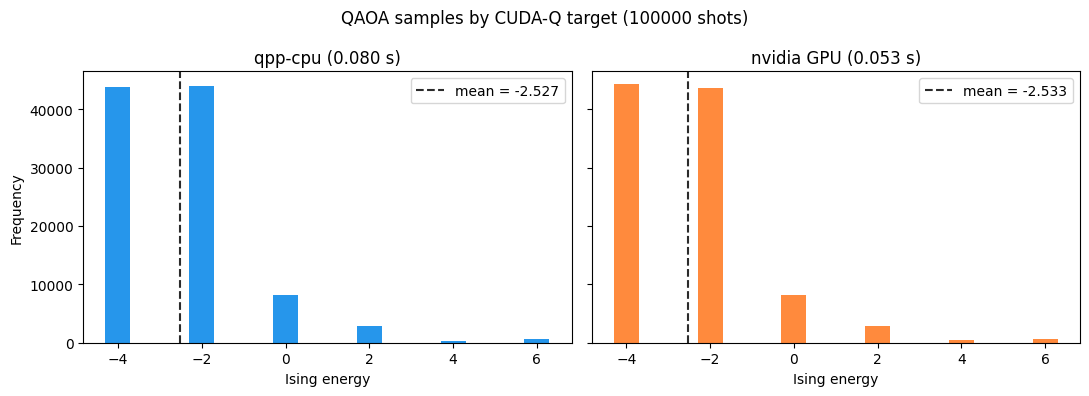

In [ ]:
def energy_distribution(decoded_samples):
    counts: Counter[float] = Counter()
    for energy, occ in zip(decoded_samples.energy, decoded_samples.num_occurrences):
        counts[energy] += occ
    energies = sorted(counts.keys())
    return energies, [counts[energy] for energy in energies]


if gpu_decoded is not None:
    energy_delta = abs(cpu_energy - gpu_energy)
    print(f"mean-energy difference: {energy_delta:.4f}")
    assert energy_delta < (0.5 if docs_test_mode else 0.15)

fig, axes = plt.subplots(
    1,
    len(target_runs),
    figsize=(5.5 * len(target_runs), 4),
    sharey=True,
)
if len(target_runs) == 1:
    axes = [axes]
for ax, (target_name, decoded_samples, mean_energy, elapsed, color) in zip(
    axes, target_runs
):
    energies, counts = energy_distribution(decoded_samples)
    ax.bar(energies, counts, width=0.6, color=color)
    ax.axvline(
        mean_energy,
        color="#2B2B2B",
        linestyle="--",
        linewidth=1.5,
        label=f"mean = {mean_energy:+.3f}",
    )
    ax.set_xticks(energies)
    ax.set_title(f"{target_name} ({elapsed:.3f} s)")
    ax.set_xlabel("Ising energy")
    ax.legend()

axes[0].set_ylabel("Frequency")
fig.suptitle(f"QAOA samples by CUDA-Q target ({benchmark_shots} shots)")
fig.tight_layout()
plt.show()

## 古典制御フローを含む場合: `STATIC` artifactと`RUNNABLE` artifact

上のQAOAアンザッツを含む多くの変分回路は、`ExecutionMode.STATIC`にトランスパイルされます。
`STATIC` artifactでは、生成されたCUDA-Qソースに明示的な終端測定は入りません。そのため、CUDA-Qの`sample` APIと`observe` APIに対応しています。

Qamomileの量子カーネルは、ハードウェアレベルの実行を想定し、回路途中の測定結果に基づく古典制御フローを記述することができます（詳しくは[古典制御フローパターン](../tutorial/07_classical_flow_patterns.ipynb)を参照してください）。
そのため、量子カーネルが`if`分岐や`while`ループのようなランタイム測定に依存する制御フローを含む場合、CUDA-Q連携は`ExecutionMode.RUNNABLE` artifactを出力します。
`RUNNABLE` artifactでは、生成されたソースに明示的な`mz(...)`測定が入り、`cudaq.run()`で実行されます。
次の小さなfeed-forward回路で、この経路を確認します。

In [72]:
@qmc.qkernel
def measurement_feed_forward() -> qmc.Bit:
    q0 = qmc.qubit("q0")
    q1 = qmc.qubit("q1")
    q0 = qmc.x(q0)
    bit = qmc.measure(q0)
    if bit:
        q1 = qmc.x(q1)
    return qmc.measure(q1)


runnable_executable = transpiler.transpile(measurement_feed_forward)
runnable_circuit = runnable_executable.get_first_circuit()
assert runnable_circuit is not None
assert runnable_circuit.execution_mode == ExecutionMode.RUNNABLE
assert "mz(" in runnable_circuit.source
assert "if " in runnable_circuit.source

print("execution_mode:", runnable_circuit.execution_mode.value)
print(runnable_circuit.source)

execution_mode: runnable
@cudaq.kernel
def _qamomile_kernel() -> list[bool]:
    q = cudaq.qvector(2)
    __b0 = False
    __b1 = False
    x(q[0])
    __b0 = mz(q[0])
    if __b0:
        x(q[1])
    __b1 = mz(q[1])
    return [__b0, __b1]



`RUNNABLE` artifactでも`ExecutableProgram.sample(...)`はそのまま使えます。ただし、Executorは`cudaq.sample()`ではなく`cudaq.run()`を呼び出します。
上の例は決定的です。最初の測定は常に`1`になるため、分岐で`q1`が反転し、戻り値のbitも常に`1`になります。

In [73]:
runnable_shots = 128
runnable_sample = runnable_executable.sample(executor, shots=runnable_shots).result()
print(runnable_sample.results)
assert sum(count for _, count in runnable_sample.results) == runnable_shots
assert all(value == 1 for value, _ in runnable_sample.results)

[(1, 128)]


一方、`RUNNABLE` artifactはCUDA-Qの`observe` APIには対応していません。
Qamomileでは、`RUNNABLE` artifactに対して`estimate()`を呼ぶと`TypeError`でこの違いを通知します。

In [74]:
try:
    executor.estimate(runnable_circuit, qm_o.Z(0))
except TypeError as exc:
    print(
        type(exc).__name__,
        "`RUNNABLE` CUDA-Q回路は`observe` APIに対応していません。",
    )
else:
    raise AssertionError("RUNNABLE CUDA-Q circuits must reject observe()")

TypeError `RUNNABLE` CUDA-Q回路は`observe` APIに対応していません。


## まとめ

このチュートリアルでは、MaxCut向けのQAOA量子カーネルをCUDA-Qへトランスパイルし、サンプリング、期待値計算、CPU/GPU targetの切り替え、古典制御フローを含む回路の実行までを確認しました。

- `CudaqTranspiler`が出力するCUDA-Q artifactはPythonソースとして確認でき、ランタイムパラメータを保ったまま再利用できます。
- 同じ`ExecutableProgram`を`qpp-cpu`と`nvidia` GPU targetで実行でき、targetの選択はexecutor側で切り替えられます。
- `CudaqExecutor`はQAOA形式のサンプリングと、CUDA-Qの`observe` APIを使うノイズなし期待値計算の両方を扱えます。
- ランタイム測定に依存する古典制御フローを含む量子カーネルは`ExecutionMode.RUNNABLE`として出力され、`cudaq.run()`経由で実行されます。

### 関連ページ

- [QURI Partsサポート](quri_parts_support.ipynb)では、同じMaxCut QAOAの流れをQURI Parts連携で扱います。
- [Qiskitサポート](qiskit_support.ipynb)では、同じ流れをQiskitで扱い、Aerシミュレータ、Qiskit primitive、Qiskitネイティブの回路機能も確認します。